In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('.')
from utils.dataset import LMDBDatabase

## Dataset Stat

In [6]:
db_name = 'bpep'
meta_path = f'data_train/{db_name}/dfs/meta_uni.csv'
df_meta_bpep = pd.read_csv(meta_path)

db_name = 'cpep'
meta_path = f'data_train/{db_name}/dfs/meta_uni.csv'
df_meta_cpep = pd.read_csv(meta_path)

In [7]:
# remove abnormal data_ids
remove_data_ids = ['cpep_8ebk', 'cpep_7yuz']
df_meta_cpep = df_meta_cpep[~df_meta_cpep['data_id'].isin(remove_data_ids)]

In [8]:
db_name = 'pepbdb'
lmdb_path = f'data/{db_name}/lmdb/peptide.lmdb' # PepBDB test set
lmdb_pepbdb = LMDBDatabase(lmdb_path, readonly=True)
meta_pepbdb_dict = {}
for i, data_id in enumerate(lmdb_pepbdb.get_all_keys()):
    meta_pepbdb_dict[data_id] = lmdb_pepbdb[data_id]['peptide_pep_len']
df_meta_pepbdb = pd.DataFrame.from_dict(meta_pepbdb_dict, orient='index', columns=['len_pep']).reset_index(names='data_id')
df_meta_pepbdb['pdbid'] = df_meta_pepbdb['data_id'].str.split('_').str[1]

In [9]:
print('bpep:', df_meta_bpep.shape[0])
print('cpep:', df_meta_cpep.shape[0])
print('pepbdb:', df_meta_pepbdb.shape[0])

bpep: 102
cpep: 27
pepbdb: 79


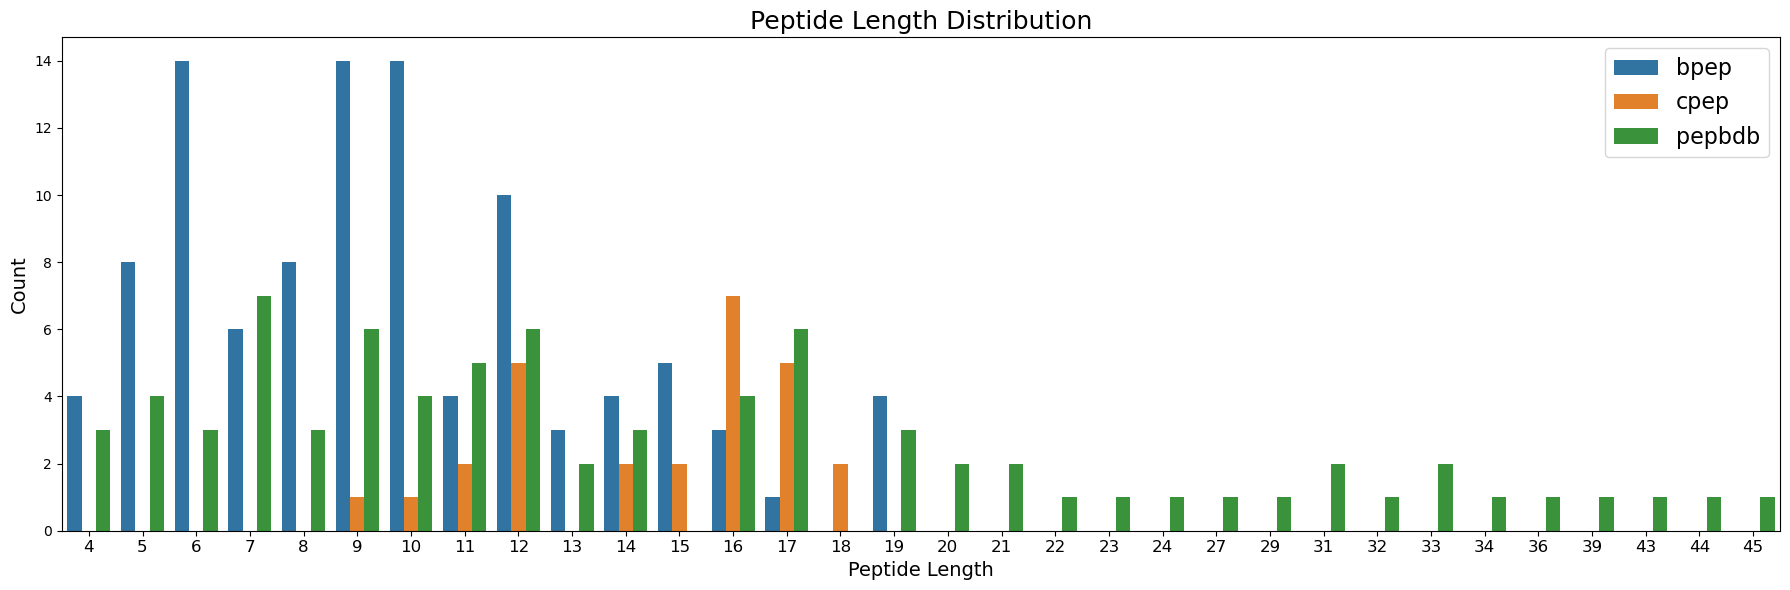

In [12]:
df_meta_bpep['db_name'] = 'bpep'
df_meta_cpep['db_name'] = 'cpep'
df_meta_pepbdb['db_name'] = 'pepbdb'
df_meta = pd.concat([df_meta_bpep, df_meta_cpep, df_meta_pepbdb])

plt.figure(figsize=(18, 6))

sns.countplot(data=df_meta, x='len_pep', hue='db_name', dodge=True)

plt.title('Peptide Length Distribution', fontsize=18)
plt.xlabel('Peptide Length', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(fontsize=12)

plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('./metric_stat/peptide_length_distribution.png', dpi=300)
plt.show()

In [13]:
set(df_meta_pepbdb['pdbid']).intersection(set(df_meta_bpep['pdbid']))

set()

In [14]:
set(df_meta_pepbdb['pdbid']).intersection(set(df_meta_cpep['pdbid']))

set()

In [15]:
set(df_meta_bpep['pdbid']).intersection(set(df_meta_cpep['pdbid']))

{'8dvl', '8gqa', '8qfz'}

## Docking Metrics

### Load Data

- keep only successful docking: tag is `np.nan`

- remove all failed docking: `nonstd, incomp, bad`

In [16]:
def rmsd_ca_check(df_metric, threshold=1e-2):
    # 检查 PDBparser 和 TM-align 计算的RMSD-CA-BA 是否一致
    df_metric = df_metric.copy()
    df_metric['check'] = df_metric['rmsd_ca_ba'] - df_metric['rmsd_ca_ba_tmscore']
    df_metric['check'] = df_metric['check'].apply(lambda x: True if abs(x) < threshold or pd.isna(x) else False)
    count = df_metric[df_metric['check']==False].shape[0]
    
    if count > 0:
        print(f"Warning: {count} rows have RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) difference greater than {threshold}")
    else:
        print("Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent")

def dock_metric_stat(gen_dir):
    key_col = 'filename_key'

    # gen_info.csv
    df_gen = pd.read_csv(os.path.join(gen_dir, 'gen_info.csv'))

    # 2. metrics files
    file_configs = {
        'rmsd_pdb.csv': ['rmsd'],
        'dockq_pdb.csv': ['dockq', 'irmsd', 'lrmsd'],
        'rmsd_ca_pdb.csv': ['rmsd_ca_ta', 'rmsd_ca_ba'],
        'tmscore_pdb.csv': ['tmscore', 'rmsd_ca_ba']
    }

    def add_filename_key(df, source_name):
        if 'filename' not in df.columns:
            raise KeyError(f"Missing required column 'filename' in {source_name}")

        df = df.copy()
        df[key_col] = df['filename'].astype(str).str.split(r'[-\.]').str[0]

        dup_mask = df[key_col].duplicated(keep=False)
        if dup_mask.any():
            dup_keys = sorted(df.loc[dup_mask, key_col].unique().tolist())
            raise ValueError(
                f"Duplicate filename key(s) found in {source_name}: {dup_keys[:10]}"
            )
        return df

    df_final = add_filename_key(df_gen, 'gen_info.csv')

    for file_name, columns in file_configs.items():
        file_path = os.path.join(gen_dir, file_name)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Required file missing: {file_name}")

        df_temp = pd.read_csv(file_path)

        # tmscore: rename rmsd_ca_ba to rmsd_ca_ba_tmscore
        if file_name == 'tmscore_pdb.csv':
            df_temp = df_temp.rename(columns={'rmsd_ca_ba': 'rmsd_ca_ba_tmscore'})
            columns = [c if c != 'rmsd_ca_ba' else 'rmsd_ca_ba_tmscore' for c in columns]
        
        required_cols = ['filename'] + columns
        missing_cols = [c for c in required_cols if c not in df_temp.columns]
        if missing_cols:
            raise KeyError(f"Missing required column(s) in {file_name}: {missing_cols}")

        df_temp = add_filename_key(df_temp[required_cols], file_name)

        base_keys = set(df_final[key_col])
        temp_keys = set(df_temp[key_col])
        if base_keys != temp_keys:
            only_base = sorted(list(base_keys - temp_keys))
            only_temp = sorted(list(temp_keys - base_keys))
            raise ValueError(
                f"Filename key mismatch between gen_info.csv and {file_name}. "
                f"Only in gen_info.csv (first 10): {only_base[:10]}, "
                f"only in {file_name} (first 10): {only_temp[:10]}"
            )

        df_final = df_final.merge(
            df_temp[[key_col] + columns],
            on=key_col,
            how='left',
            validate='one_to_one'
        )

    # remove temporary merge key
    df_final = df_final.drop(columns=[key_col])

    # 4. keep only successful dock: tag is np.nan
    ## remove failed dock: nonstd, incomp, bad
    count_all = df_final.shape[0]
    df_final = df_final[df_final['tag'].isna()]
    print('Dropped %d rows with failed dock' % (count_all - df_final.shape[0]))

    # 4. check rmsd_ca_ba consistency: by PDBparser and TM-Align
    rmsd_ca_check(df_final)
    df_final.drop(columns=['rmsd_ca_ba_tmscore'], inplace=True)

    return df_final

In [17]:
gen_dir_bpep = './outputs_test/dock_bpep/base_pxm_20260318_165320'
df_gen_bpep = dock_metric_stat(gen_dir_bpep)

Dropped 48 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [18]:
gen_dir_cpep = './outputs_test/dock_cpep/base_pxm_20260318_170001'
df_gen_cpep = dock_metric_stat(gen_dir_cpep)

Dropped 4400 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [19]:
gen_dir_pepbdb = './outputs_test/dock_pepbdb/base_pxm_20260317_172745'
df_gen_pepbdb = dock_metric_stat(gen_dir_pepbdb)

Dropped 670 rows with failed dock
Success: All RMSD-CA BA (PDBparser) and RMSD-CA BA (TM-Align) are consistent


In [20]:
df_gen_merge = pd.concat([df_gen_bpep, df_gen_cpep, df_gen_pepbdb], ignore_index=True)

### RMSD / TM-score / DockQ

In [21]:
target_cols = ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba', 'dockq', 'tmscore']

In [22]:
# Metrics-1: by mean of each data_id
df_mean = df_gen_merge.groupby('data_id')[target_cols].mean().reset_index()
df_mean['db'] = df_mean['data_id'].str.split('_').str[0]
df_mean.head()

,data_id,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore,db
0,bpep_7prx,10.530774,9.931626,5.354018,0.374211,0.153535,bpep
1,bpep_7qwv,11.211448,10.507821,5.724814,0.311392,0.187576,bpep
2,bpep_7sxf,9.260926,9.461313,2.983720,0.439795,0.305298,bpep
3,bpep_7sxh,9.647865,9.304374,3.060776,0.393295,0.261792,bpep
4,bpep_7tmy,7.866014,7.151036,1.595942,0.550035,0.422412,bpep


In [23]:
# Metrics-2: by max cfd_traj of each data_id
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
df_best_cfd.head()

,data_id,db,cfd_traj,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore
0,bpep_7prx,bpep,-0.464588,7.443994,6.298555,4.983485,0.515,0.10333
1,bpep_7qwv,bpep,-0.266619,4.399027,3.204649,3.059636,0.694,0.27589
2,bpep_7sxf,bpep,-0.230480,2.337286,2.546990,2.150659,0.792,0.51968
3,bpep_7sxh,bpep,-0.226187,1.575755,1.310722,1.021160,0.917,0.41369
4,bpep_7tmy,bpep,0.238092,1.004747,0.672509,0.270346,0.976,0.80547


In [ ]:
# Metrics-3: by oracle of each data_id
min_cols = ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba']
max_cols = ['dockq', 'tmscore']

df_min = df_gen_merge.groupby('data_id')[min_cols].min()
df_max = df_gen_merge.groupby('data_id')[max_cols].max()

df_oracle = pd.concat([df_min, df_max], axis=1).reset_index()
df_oracle['db'] = df_oracle['data_id'].str.split('_').str[0]

df_oracle.head()

,data_id,rmsd,rmsd_ca_ta,rmsd_ca_ba,dockq,tmscore,db
0,bpep_7prx,5.829182,4.656191,3.670846,0.676,0.27065,bpep
1,bpep_7qwv,2.988616,2.263850,2.150560,0.790,0.36926,bpep
2,bpep_7sxf,1.509333,1.434162,1.280068,0.916,0.72789,bpep
3,bpep_7sxh,1.392944,1.056552,0.707488,0.939,0.58068,bpep
4,bpep_7tmy,0.562782,0.452144,0.235948,0.988,0.83213,bpep


In [25]:
def plot_metrics_bar(df_plot, output_path=None):
    
    target_cols = {'rmsd': 'All-atom RMSD', 
               'rmsd_ca_ta': 'Cα RMSD (TA)', 
               'rmsd_ca_ba': 'Cα RMSD (BA)', 
               'dockq': 'DockQ', 
               'tmscore': 'TM-score'}

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 5, figsize=(24, 3))

    for i, col in enumerate(target_cols):
        sns.barplot(
            data=df_plot, 
            x=col, 
            y='db', 
            ax=axes[i], 
            hue='db', 
            errorbar=('ci', 95), 
            capsize=0.1, 
            palette='muted',
            dodge=False
        )
        
        # fontsize
        ## x, y ticklabel
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        ## x, y label
        axes[i].set_xlabel('', fontsize=18)
        axes[i].set_ylabel('', fontsize=18)
        ## subplot title
        axes[i].set_title(f'{target_cols[col]}', fontsize=20, pad=15)

        # xlim
        if col in ['rmsd', 'rmsd_ca_ta', 'rmsd_ca_ba']:
            axes[i].set_xlim(0, 14)
        elif col in ['dockq', 'tmscore']:
            axes[i].set_xlim(0, 1)

        # legend and yticklabels
        if i < 4:
            # 前4个子图：移除自带图例
            legend = axes[i].get_legend()
            if legend is not None:
                legend.remove()
            # 隐藏除了第一个图以外的 y 轴刻度标签
            if i > 0:
                axes[i].set_yticklabels([])
        else:
            # 第5个子图：设置外部图例
            axes[i].legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14) # title_fontsize=14
            axes[i].set_yticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

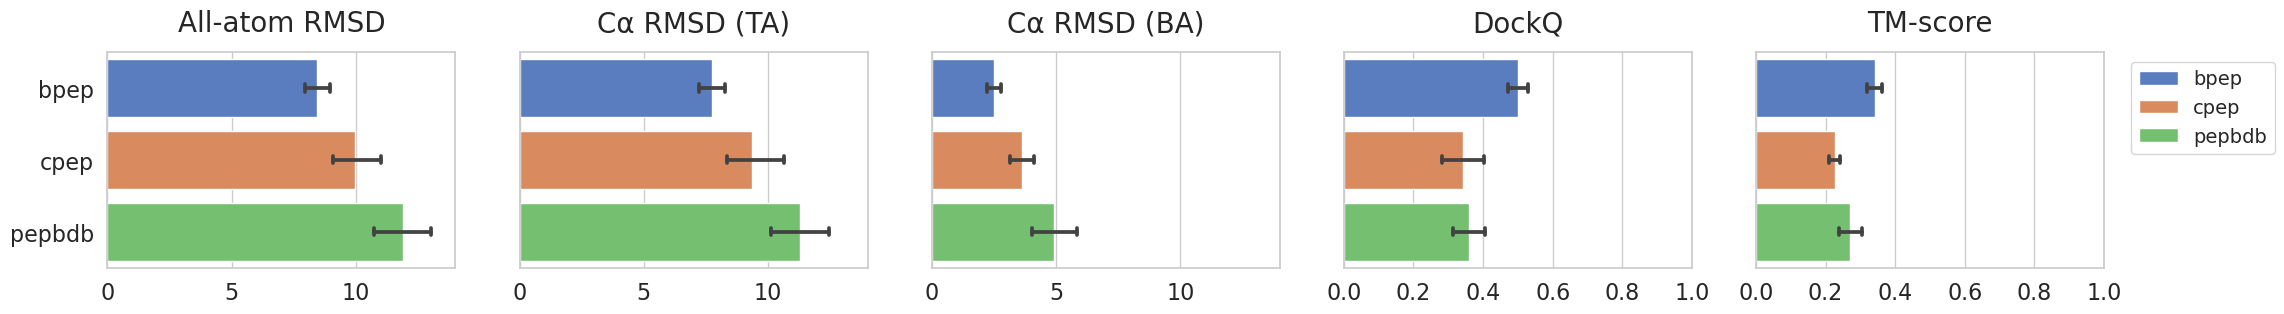

In [26]:
plot_metrics_bar(df_mean, output_path='./metric_stat/pepdock_metrics_bar_mean.png')

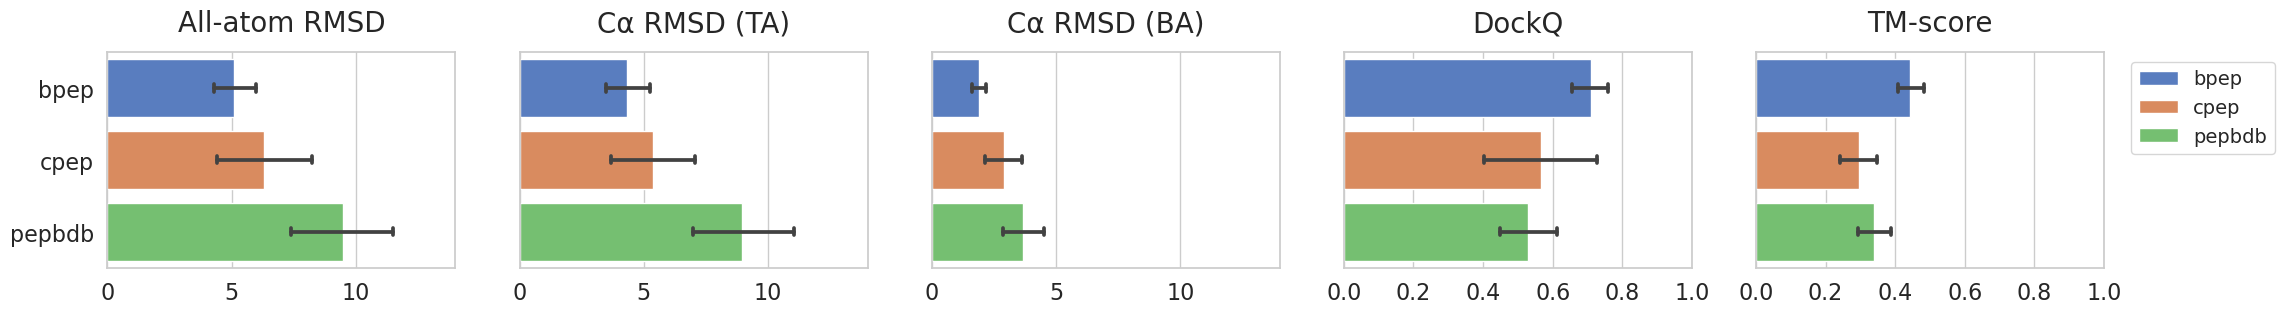

In [27]:
plot_metrics_bar(df_best_cfd, output_path='./metric_stat/pepdock_metrics_bar_best_cfd.png')

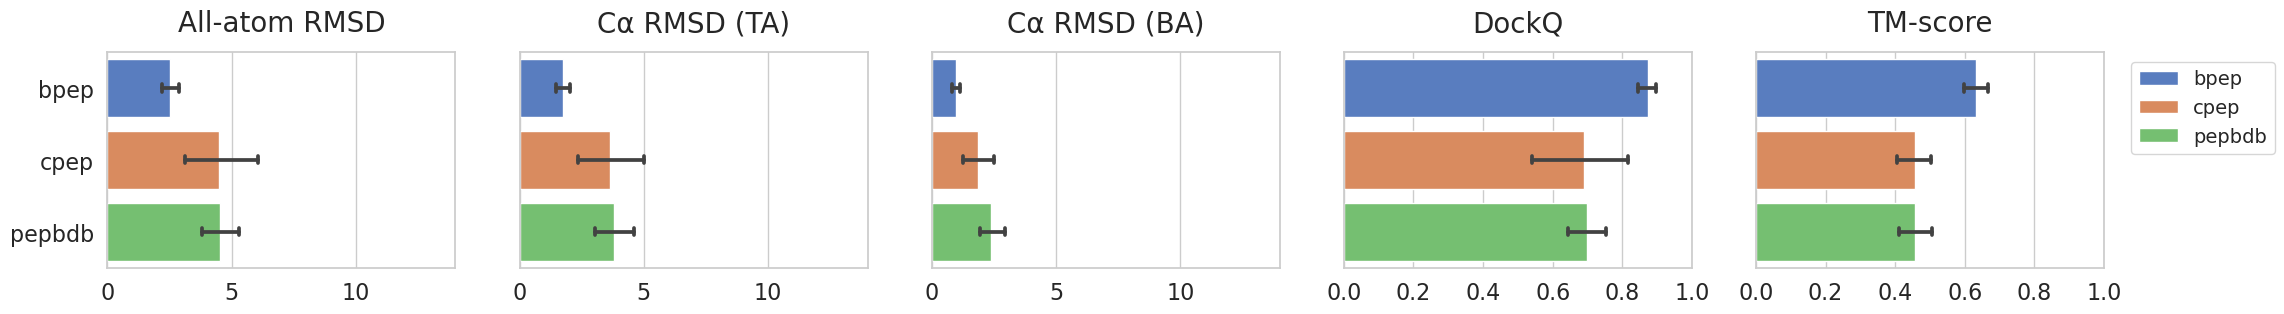

In [ ]:
plot_metrics_bar(df_oracle, output_path='./metric_stat/pepdock_metrics_bar_oracle.png')

### Success Rate

In [29]:
def cal_success_rate(df_metric):
    # 1. label success or not (True/False)
    df_temp = df_metric.assign(is_success=df_metric['rmsd_ca_ta'] < 2)
    
    # 2. 聚合统计：同时计算成功数(sum)和总数(count)
    # 因为 True 在计算时等同于 1，False 等同于 0，所以 sum 结果就是分子
    success_stats = (
        df_temp.groupby('db')['is_success']
        .agg(['sum', 'count'])
        .reset_index()
    )
    
    # 3. 计算百分比
    success_stats['percentage'] = (success_stats['sum'] / success_stats['count']) * 100
    
    # 4. 格式化输出：百分比 (分子/分母)
    # 例如：15.5% (31/200)
    success_stats['success_rate_label'] = success_stats.apply(
        lambda row: f"{int(row['sum'])}/{int(row['count'])} ({row['percentage']:.2f}%)", 
        axis=1
    )
    
    return success_stats

In [ ]:
df_success_mean = cal_success_rate(df_mean)
df_success_best_cfd = cal_success_rate(df_best_cfd)
df_success_oracale = cal_success_rate(df_oracle)

df_success_merge = pd.concat([df_success_mean[['db', 'success_rate_label']], df_success_best_cfd['success_rate_label'], df_success_oracale['success_rate_label']], axis=1)
df_success_merge.columns = ['db', 'mean', 'best_cfd', 'oracle']
df_success_merge.to_csv('./metric_stat/pepdock_success_rate.csv', index=False)
df_success_merge

,db,mean,best_cfd,oracle
0,bpep,2/102 (1.96%),40/102 (39.22%),69/102 (67.65%)
1,cpep,0/7 (0.00%),1/7 (14.29%),1/7 (14.29%)
2,pepbdb,0/66 (0.00%),13/66 (19.70%),18/66 (27.27%)


## Invserse-Folding Metrics

### Load Data

In [32]:
import ast

def pepinv_metric_stat(gen_dir):
    df_sc = pd.read_csv(os.path.join(gen_dir, 'sc_metrics.csv'))
    # keep only successful sample: tag is np.nan
    df_sc = df_sc[df_sc['succ']]
    df_sc['sc_rmsd_list'] = df_sc['sc_rmsd_list'].apply(ast.literal_eval)
    return df_sc

In [33]:
gen_dir_bpep = './outputs_test/pepinv_bpep/base_pxm_20260319_115259'
df_scrmsd_bpep = pepinv_metric_stat(gen_dir_bpep)

In [34]:
gen_dir_cpep = './outputs_test/pepinv_cpep/base_pxm_20260320_223246'
df_scrmsd_cpep = pepinv_metric_stat(gen_dir_cpep)

In [35]:
gen_dir_pepbdb = './outputs_test/pepinv_pepbdb/base_pxm_20260319_163803'
df_scrmsd_pepbdb = pepinv_metric_stat(gen_dir_pepbdb)

### sc-RMSD

In [36]:
df_scrmsd_cpep.groupby('data_id')['aa_recovery_rate'].max().reset_index()

,data_id,aa_recovery_rate
0,cpep_7y8d,NaN
1,cpep_7y90,NaN
2,cpep_7ya5,NaN
3,cpep_7zrt,NaN
4,cpep_8dvl,0.500000
5,cpep_8ei0,NaN
6,cpep_8ei2,0.266667
7,cpep_8ei4,0.312500
8,cpep_8ei8,0.411765
9,cpep_8f4b,NaN


In [37]:
def plot_sc_rmsd_hist(df_scrmsd, db_name, output_path=None):
    
    sc_rmsd_list = []
    for value in df_scrmsd['sc_rmsd_list']:
        sc_rmsd_list += value
    
    # Median
    sc_median = np.median(sc_rmsd_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(sc_rmsd_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 1.5, y_max * 0.9, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Side-chain RMSD of\nrecovered residues ($\AA$)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

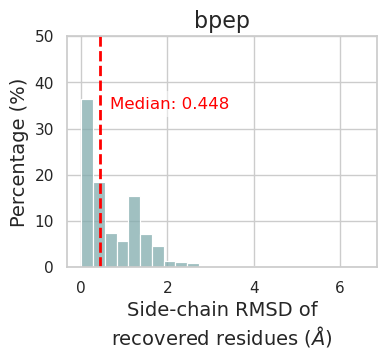

In [38]:
plot_sc_rmsd_hist(df_scrmsd_bpep, db_name='bpep', output_path='./metric_stat/pepinv_sc_rmsd_hist_bpep.png')

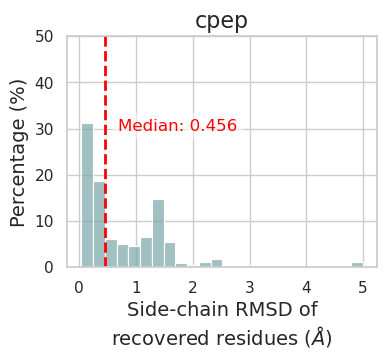

In [39]:
plot_sc_rmsd_hist(df_scrmsd_cpep, db_name='cpep', output_path='./metric_stat/pepinv_sc_rmsd_hist_cpep.png')

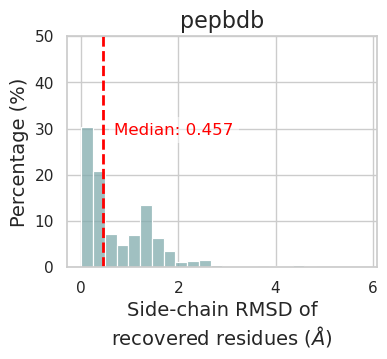

In [40]:
plot_sc_rmsd_hist(df_scrmsd_pepbdb, db_name='pepbdb', output_path='./metric_stat/pepinv_sc_rmsd_hist_pepbdb.png')

### sequence recovery rate

In [41]:
def plot_seq_recovery_hist(df_metric, db_name, output_path=None):
    
    
    
    df_metric_max = df_metric.groupby('data_id')['aa_recovery_rate'].max().reset_index()
    seq_recovery_list = df_metric_max['aa_recovery_rate'].dropna().tolist()
    seq_recovery_list = [value * 100 for value in seq_recovery_list]

    # Median
    sc_median = np.median(seq_recovery_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(seq_recovery_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 0.1, y_max * 0.9, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Sequence recovery rate (%)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    plt.xlim(0, 100)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

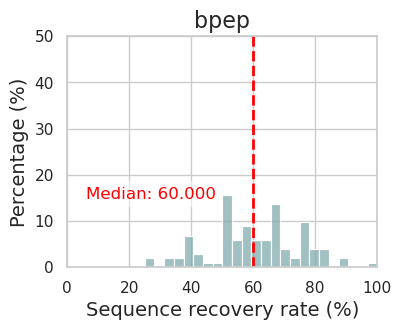

In [42]:
plot_seq_recovery_hist(df_scrmsd_bpep, db_name='bpep', output_path='./metric_stat/pepinv_seq_recovery_rate_bpep.png')

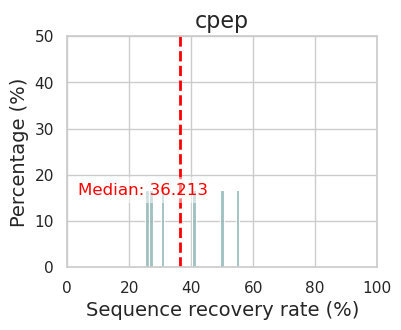

In [43]:
plot_seq_recovery_hist(df_scrmsd_cpep, db_name='cpep', output_path='./metric_stat/pepinv_seq_recovery_rate_cpep.png')

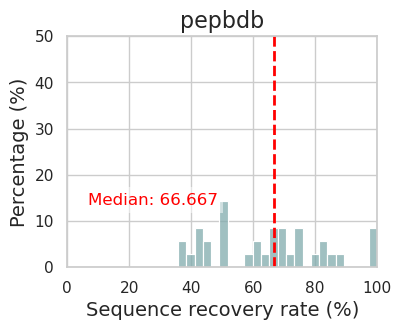

In [44]:
plot_seq_recovery_hist(df_scrmsd_pepbdb, db_name='pepbdb', output_path='./metric_stat/pepinv_seq_recovery_rate_pepbdb.png')

In [45]:
df_scrmsd_bpep

,data_id,non_std_data,filename,succ,gt_seq,aaseq,sc_rmsd_list,aa_recovery_rate
0,bpep_7prx,False,89.pdb,True,PPQEAEEPSLLKKLLLAPA,GAATGAYPETIERLLQESA,"[0.24258047, 1.8164213, 1.2540709, 0.24729775]",0.210526
1,bpep_7prx,False,191.pdb,True,PPQEAEEPSLLKKLLLAPA,GSAGGSKATLLEYILDEAD,"[1.2618443, 0.31583118, 0.16539428]",0.157895
2,bpep_7prx,False,293.pdb,True,PPQEAEEPSLLKKLLLAPA,SAPGGPKEHLIEYLMDRED,"[1.245752, 1.7826893]",0.105263
4,bpep_7prx,False,497.pdb,True,PPQEAEEPSLLKKLLLAPA,AAAGADEDFHLFRLLKFAT,"[0.1476731, 3.448183, 0.44652486, 1.791567, 0....",0.263158
5,bpep_7prx,False,599.pdb,True,PPQEAEEPSLLKKLLLAPA,AAAAGIHTKQLLELLERSD,"[0.5183021, 0.53169966, 0.16758081]",0.157895
...,...,...,...,...,...,...,...,...
19684,bpep_9f42,False,19874.pdb,True,RVFFMDDVE,FNFFDADVE,"[1.4393222, 4.0087004, 1.0326687, 1.7336245, 2...",0.555556
19685,bpep_9f42,False,19976.pdb,True,RVFFMDDVE,SIEDEDDVD,"[1.1298826, 1.271787, 1.7809938]",0.333333
19686,bpep_9f42,False,20078.pdb,True,RVFFMDDVE,QVFFLDSVD,"[1.7543534, 1.4650376, 3.9317245, 1.0939102, 0...",0.555556
19687,bpep_9f42,False,20180.pdb,True,RVFFMDDVE,FLYELDDVE,"[0.17173384, 0.5181708, 1.7182518, 2.43525]",0.444444


## Peptide Design Metrics

### Load Data

- keep only successful docking: tag is `np.nan`

- remove all failed docking: `nonstd, incomp, bad`

In [2]:
def pepdesign_metric_stat(gen_dir):
    key_col = 'filename_key'

    # gen_info.csv
    df_gen = pd.read_csv(os.path.join(gen_dir, 'gen_info.csv'))

    # 2. metrics files
    file_configs = {
        # 'rmsd_pdb.csv': ['rmsd'],
        # 'dockq_pdb.csv': ['dockq', 'irmsd', 'lrmsd'],
        'rmsd_ca_pdb.csv': ['rmsd_ca_ta', 'rmsd_ca_ba'],
        'tmscore_pdb.csv': ['tmscore', 'rmsd_ca_ba'],
        'metrics.csv': ['seq_iden', 'rmsd', 'ss', 'ss_gt', 'phi', 'psi'],
        'rama_stat.csv': ['total_angle_numbers', 'total_accept', 'accept_rate', 'total_favoured', 'favoured_rate'],
        # 'rama_stat_gt.csv': ['total_angle_numbers', 'total_accept', 'accept_rate', 'total_favoured', 'favoured_rate']
    }

    def add_filename_key(df, source_name):
        if 'filename' not in df.columns:
            raise KeyError(f"Missing required column 'filename' in {source_name}")

        df = df.copy()
        df[key_col] = df['filename'].astype(str).str.split(r'[-_\.]').str[0] # '_' for _gt.pdb in rama_stat_gt.csv

        dup_mask = df[key_col].duplicated(keep=False)
        if dup_mask.any():
            dup_keys = sorted(df.loc[dup_mask, key_col].unique().tolist())
            raise ValueError(
                f"Duplicate filename key(s) found in {source_name}: {dup_keys[:10]}"
            )
        return df

    df_final = add_filename_key(df_gen, 'gen_info.csv')

    for file_name, columns in file_configs.items():
        file_path = os.path.join(gen_dir, file_name)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Required file missing: {file_name}")

        df_temp = pd.read_csv(file_path)

        # tmscore: rename rmsd_ca_ba to rmsd_ca_ba_tmscore
        if file_name == 'tmscore_pdb.csv':
            df_temp = df_temp.rename(columns={'rmsd_ca_ba': 'rmsd_ca_ba_tmscore'})
            columns = ['tmscore', 'rmsd_ca_ba_tmscore']
        elif file_name == 'metrics.csv':
            df_temp = df_temp.rename(columns={'rmsd': 'rmsd_bb'})
            columns = ['seq_iden', 'rmsd_bb', 'ss', 'ss_gt', 'phi', 'psi']
        # elif file_name == 'rama_stat.csv':
        #     df_temp = df_temp.rename(columns={'accept_rate': 'rama_accept_rate', 'favoured_rate': 'rama_favoured_rate'})
        #     columns = ['rama_accept_rate', 'rama_favoured_rate']
        
        required_cols = ['filename'] + columns
        missing_cols = [c for c in required_cols if c not in df_temp.columns]
        if missing_cols:
            raise KeyError(f"Missing required column(s) in {file_name}: {missing_cols}")

        df_temp = add_filename_key(df_temp[required_cols], file_name)

        base_keys = set(df_final[key_col])
        temp_keys = set(df_temp[key_col])
        if base_keys != temp_keys:
            only_base = sorted(list(base_keys - temp_keys))
            only_temp = sorted(list(temp_keys - base_keys))
            raise ValueError(
                f"Filename key mismatch between gen_info.csv and {file_name}. "
                f"Only in gen_info.csv (first 10): {only_base[:10]}, "
                f"only in {file_name} (first 10): {only_temp[:10]}"
            )

        df_final = df_final.merge(
            df_temp[[key_col] + columns],
            on=key_col,
            how='left',
            validate='one_to_one'
        )

    # remove temporary merge key
    df_final = df_final.drop(columns=[key_col])

    df_final_full = df_final.copy()

    # 4. keep only successful pepdesign: tag is np.nan
    ## remove failed pepdesign: nonstd, incomp, bad
    count_all = df_final.shape[0]
    df_final = df_final[df_final['tag'].isna()]
    print('Dropped %d rows with failed pepdesign' % (count_all - df_final.shape[0]))

    # 4. check rmsd_ca_ba consistency: by PDBparser and TM-Align
    # rmsd_ca_check(df_final)
    # df_final.drop(columns=['rmsd_ca_ba_tmscore'], inplace=True)

    return df_final, df_final_full

In [3]:
gen_dir_bpep = './outputs_test/pepdesign_bpep/base_pxm_20260325_130808'
df_gen_bpep, df_gen_bpep_full = pepdesign_metric_stat(gen_dir_bpep)

Dropped 7033 rows with failed pepdesign


In [4]:
# gen_dir_cpep = './outputs_test/dock_cpep/base_pxm_20260318_170001'
# df_gen_cpep = dock_metric_stat(gen_dir_cpep)

In [5]:
gen_dir_pepbdb = './outputs_test/pepdesign_pepbdb/base_pxm_20260325_130506'
df_gen_pepbdb, df_gen_pepbdb_full = pepdesign_metric_stat(gen_dir_pepbdb)

Dropped 2217 rows with failed pepdesign


In [6]:
df_gen_merge = pd.concat([df_gen_bpep, df_gen_pepbdb], ignore_index=True) # df_gen_cpep, 
df_gen_merge_full = pd.concat([df_gen_bpep_full, df_gen_pepbdb_full], ignore_index=True)

### RMSD / TM-score / DockQ

In [39]:
target_cols = ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba', 'tmscore']

In [40]:
# Metrics-1: by mean of each data_id
df_mean = df_gen_merge.groupby('data_id')[target_cols].mean().reset_index()
df_mean['db'] = df_mean['data_id'].str.split('_').str[0]
df_mean.head()

,data_id,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore,db
0,bpep_7prx,16.371824,16.488504,6.801121,0.159109,bpep
1,bpep_7qwv,13.387682,13.391817,6.171336,0.169774,bpep
2,bpep_7sxf,10.131577,10.108701,5.279954,0.203777,bpep
3,bpep_7sxh,10.065151,9.975478,4.895910,0.215915,bpep
4,bpep_7tmy,8.002096,7.935847,1.824067,0.403169,bpep


In [41]:
# Metrics-2: by max cfd_traj of each data_id
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)
df_best_cfd.head()

,data_id,db,cfd_traj,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore
0,bpep_7prx,bpep,0.544833,11.039659,11.246176,7.040817,0.12882
1,bpep_7qwv,bpep,0.621439,9.761112,9.719139,8.743685,0.05169
2,bpep_7sxf,bpep,0.581003,6.983666,7.346817,3.589381,0.19843
3,bpep_7sxh,bpep,0.551158,4.389820,4.209871,2.396008,0.28371
4,bpep_7tmy,bpep,0.717753,13.208302,12.960082,2.153285,0.40643


In [42]:
# Metrics-3: by oracle of each data_id
min_cols = ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba']
max_cols = ['tmscore'] # 'rama_accept_rate', 'rama_favoured_rate'

df_min = df_gen_merge.groupby('data_id')[min_cols].min()
df_max = df_gen_merge.groupby('data_id')[max_cols].max()

df_oracle = pd.concat([df_min, df_max], axis=1).reset_index()
df_oracle['db'] = df_oracle['data_id'].str.split('_').str[0]

df_oracle.head()

,data_id,rmsd_bb,rmsd_ca_ta,rmsd_ca_ba,tmscore,db
0,bpep_7prx,6.956961,6.959837,3.701233,0.34914,bpep
1,bpep_7qwv,3.490307,3.624128,2.946580,0.29736,bpep
2,bpep_7sxf,3.373827,3.597623,2.691976,0.41772,bpep
3,bpep_7sxh,3.082611,2.980831,0.929140,0.49405,bpep
4,bpep_7tmy,0.692105,0.668387,0.350481,0.70501,bpep


In [43]:
def plot_metrics_bar(df_plot, output_path=None):
    
    target_cols = {'rmsd_bb': 'Backbone RMSD', 
               'rmsd_ca_ta': 'Cα RMSD (TA)', 
               'rmsd_ca_ba': 'Cα RMSD (BA)', 
               # 'dockq': 'DockQ', 
               'tmscore': 'TM-score',
               # 'rama_accept_rate': 'Accept Rate',
               # 'rama_favoured_rate': 'Favoured Rate'
               }

    sns.set_theme(style="whitegrid")

    fig_num = len(target_cols)
    fig, axes = plt.subplots(1, fig_num, figsize=(18, 3))

    for i, col in enumerate(target_cols):
        sns.barplot(
            data=df_plot, 
            x=col, 
            y='db', 
            ax=axes[i], 
            hue='db', 
            errorbar=('ci', 95), 
            capsize=0.1, 
            palette='muted',
            dodge=False
        )
        
        # fontsize
        ## x, y ticklabel
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        ## x, y label
        axes[i].set_xlabel('', fontsize=18)
        axes[i].set_ylabel('', fontsize=18)
        ## subplot title
        axes[i].set_title(f'{target_cols[col]}', fontsize=20, pad=15)

        # xlim
        if col in ['rmsd_bb', 'rmsd_ca_ta', 'rmsd_ca_ba']:
            axes[i].set_xlim(0, 14)
        elif col in ['dockq', 'tmscore', 'rama_accept_rate', 'rama_favoured_rate']:
            axes[i].set_xlim(0, 1)

        # legend and yticklabels
        if i < fig_num - 1:
            # 前3个子图：移除自带图例
            legend = axes[i].get_legend()
            if legend is not None:
                legend.remove()
            # 隐藏除了第一个图以外的 y 轴刻度标签
            if i > 0:
                axes[i].set_yticklabels([])
        else:
            # 最后一个子图：设置外部图例
            axes[i].legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14) # title_fontsize=14
            axes[i].set_yticklabels([])

    plt.tight_layout()
    plt.subplots_adjust(right=0.88, top=0.9)
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

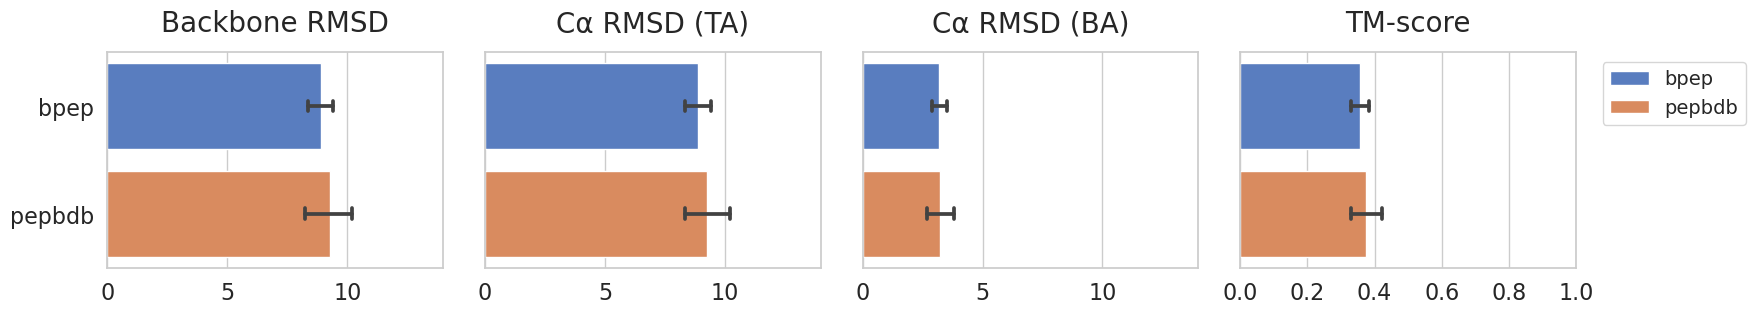

In [44]:
plot_metrics_bar(df_mean, output_path='./metric_stat/pepdesign_metrics_bar_mean.png')

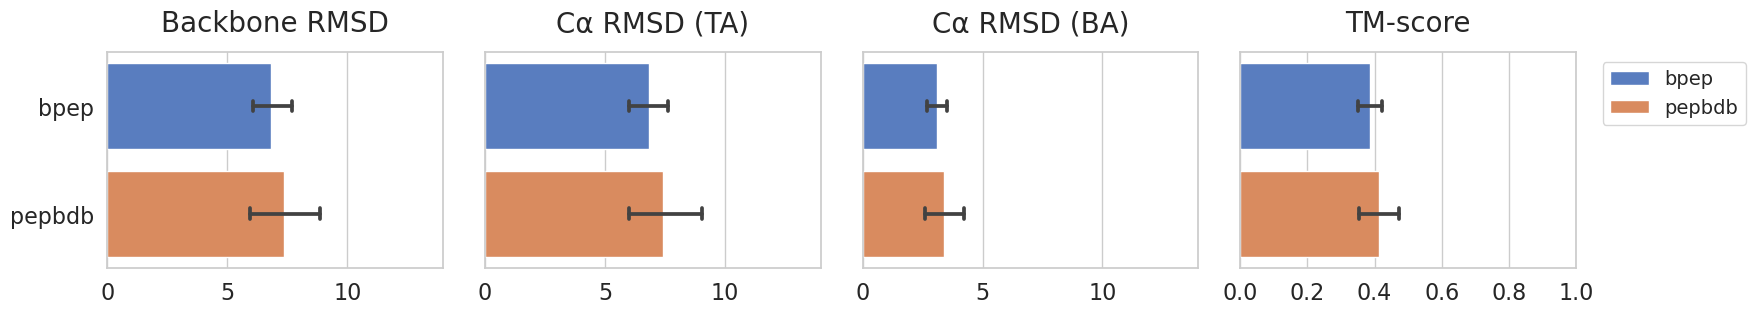

In [45]:
plot_metrics_bar(df_best_cfd, output_path='./metric_stat/pepdesign_metrics_bar_best_cfd.png')

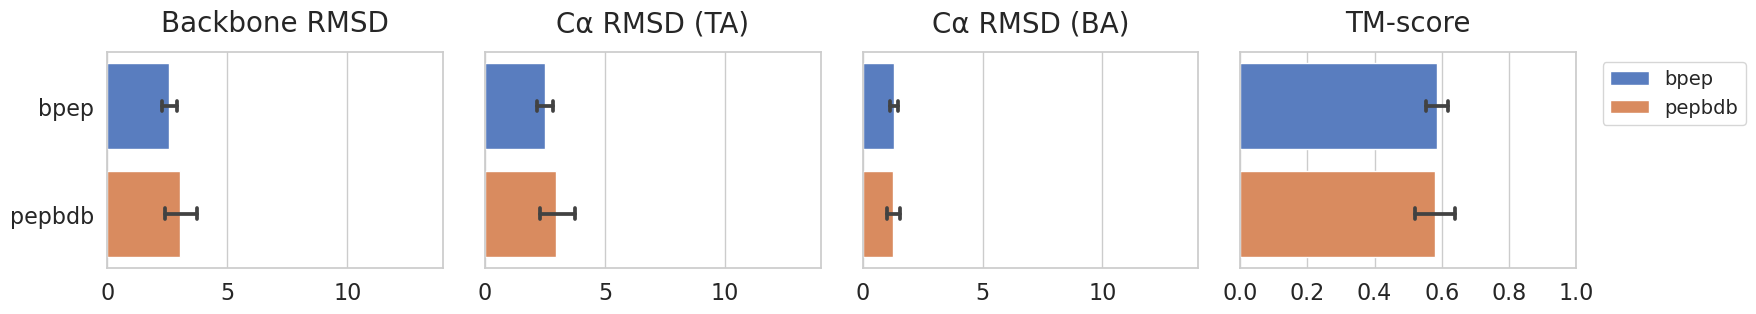

In [46]:
plot_metrics_bar(df_oracle, output_path='./metric_stat/pepdesign_metrics_bar_oracle.png')

### Success Rate

In [47]:
def cal_success_rate(df_metric):
    # 1. label success or not (True/False)
    df_temp = df_metric.assign(is_success=df_metric['rmsd_ca_ta'] < 2)
    
    # 2. 聚合统计：同时计算成功数(sum)和总数(count)
    # 因为 True 在计算时等同于 1，False 等同于 0，所以 sum 结果就是分子
    success_stats = (
        df_temp.groupby('db')['is_success']
        .agg(['sum', 'count'])
        .reset_index()
    )
    
    # 3. 计算百分比
    success_stats['percentage'] = (success_stats['sum'] / success_stats['count']) * 100
    
    # 4. 格式化输出：百分比 (分子/分母)
    # 例如：15.5% (31/200)
    success_stats['success_rate_label'] = success_stats.apply(
        lambda row: f"{int(row['sum'])}/{int(row['count'])} ({row['percentage']:.2f}%)", 
        axis=1
    )
    
    return success_stats

In [48]:
df_success_mean = cal_success_rate(df_mean)
df_success_best_cfd = cal_success_rate(df_best_cfd)
df_success_oracale = cal_success_rate(df_oracle)

df_success_merge = pd.concat([df_success_mean[['db', 'success_rate_label']], df_success_best_cfd['success_rate_label'], df_success_oracale['success_rate_label']], axis=1)
df_success_merge.columns = ['db', 'mean', 'best_cfd', 'oracle']
df_success_merge.to_csv('./metric_stat/pepdesign_success_rate.csv', index=False)
df_success_merge

,db,mean,best_cfd,oracle
0,bpep,0/102 (0.00%),18/102 (17.65%),47/102 (46.08%)
1,pepbdb,0/35 (0.00%),4/35 (11.43%),14/35 (40.00%)


### Backbone RMSD

In [55]:
thresholds = [1, 2, 3, 4, 5]

In [56]:
def bb_rmsd_stat(df_metric, thresholds):
    """
    Calculate the percentage of rmsd_bb less than each threshold for each database.
    """
    
    df_temp = df_metric.copy()
    for t in thresholds:
        df_temp[f'lt_{t}'] = (df_temp['rmsd_bb'] < t)
    
    lt_cols = [f'lt_{t}' for t in thresholds]
    df_threshold_stats = df_temp.groupby('db')[lt_cols].mean() * 100
    
    df_threshold_stats.columns = [f'rmsd_bb_lt_{t}' for t in thresholds]
    return df_threshold_stats.reset_index()

In [62]:
df_mean_bb_rmsd = bb_rmsd_stat(df_mean, thresholds)
df_best_cfd_bb_rmsd = bb_rmsd_stat(df_best_cfd, thresholds)
df_oracle_bb_rmsd = bb_rmsd_stat(df_oracle, thresholds)

In [66]:
output_path = './metric_stat/pepdesign_bb_rmsd.png'

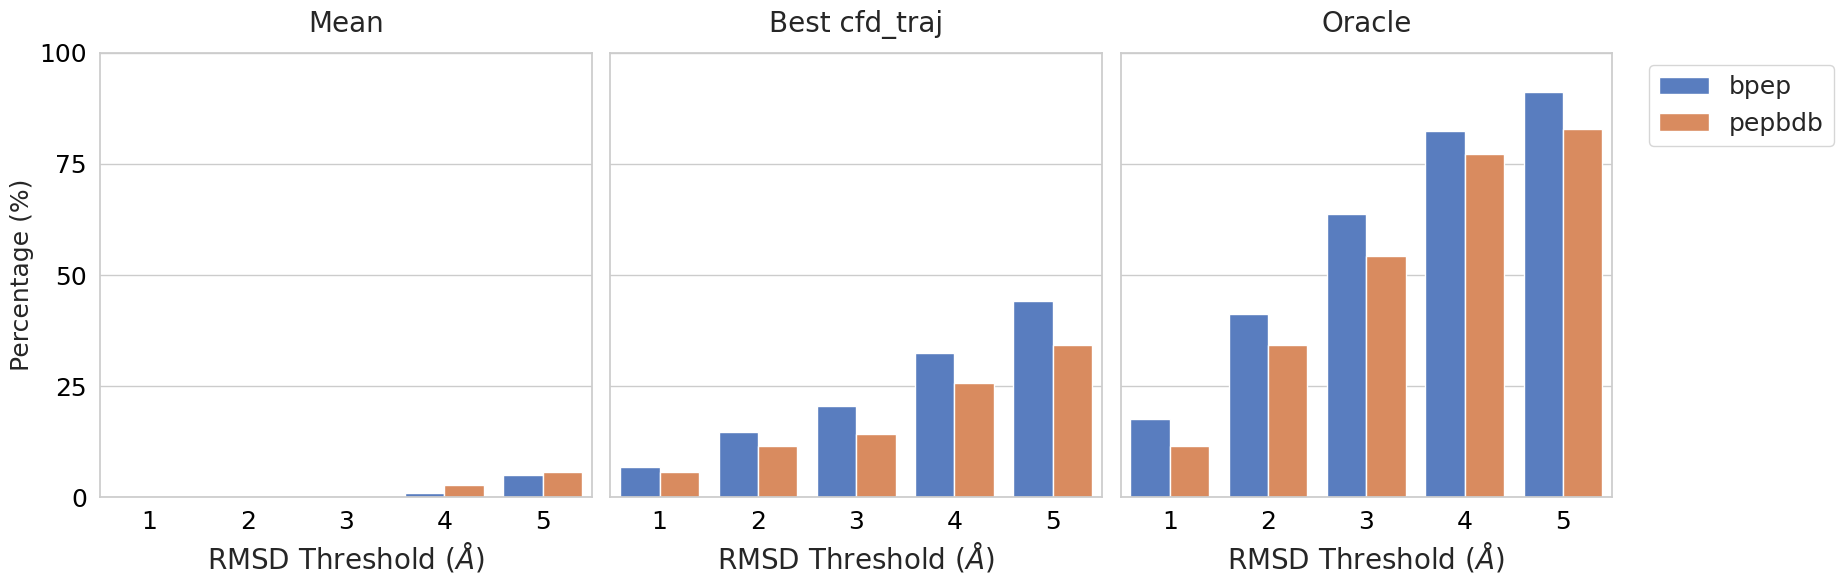

In [75]:
dfs = {
    'Mean': df_mean_bb_rmsd, 
    'Best cfd_traj': df_best_cfd_bb_rmsd, 
    'Oracle': df_oracle_bb_rmsd
}

value_vars = [f'rmsd_bb_lt_{t}' for t in thresholds]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.set_theme(style="whitegrid")

for i, (title, df_target) in enumerate(dfs.items()):
    # --- 数据处理 ---
    df_long = pd.melt(
        df_target, 
        id_vars=['db'], 
        value_vars=value_vars, 
        var_name='threshold_raw', 
        value_name='percentage'
    )
    df_long['threshold'] = df_long['threshold_raw'].str.extract('(\d+)').astype(int)

    # --- 绘图 ---
    ax = axes[i]
    sns.barplot(
        data=df_long, 
        x='threshold', 
        y='percentage', 
        hue='db', 
        ax=ax,
        palette='muted', 
        edgecolor='white'
    )

    # --- 细节设置 ---
    ax.set_title(title, fontsize=20, pad=15)
    ax.set_xlabel('RMSD Threshold ($\AA$)', fontsize=20)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.tick_params(axis='both', which='major', labelsize=18, colors='black')
    
    # 只有第一个图显示 Y 轴标签
    if i == 0:
        ax.set_ylabel('Percentage (%)', fontsize=18)
    else:
        ax.set_ylabel('')

    
    if i < 2:
        # 前两个图去掉图例
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        # 最后一个图保留图例并放到右侧外
        ax.legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=18)

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### sequence recovery rate

In [61]:
def plot_seq_recovery_hist(df_metric, db_name, output_path=None):
    
    
    
    df_metric_max = df_metric.groupby('data_id')['seq_iden'].max().reset_index()
    seq_recovery_list = df_metric_max['seq_iden'].dropna().tolist()
    seq_recovery_list = [value * 100 for value in seq_recovery_list]

    # Median
    sc_median = np.median(seq_recovery_list)

    plt.figure(figsize=(4, 3))

    ax = sns.histplot(seq_recovery_list, stat='percent', bins=24, color='#81abad', edgecolor='white')

    ax.axvline(sc_median, color='red', linestyle='--', linewidth=2, label='Median')
    y_max = ax.get_ylim()[1]
    ax.text(sc_median * 0.1, y_max * 1.2, f'Median: {sc_median:.3f}', 
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.xlabel('Sequence recovery rate (%)', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=14)
    plt.title(f'{db_name}', fontsize=16)

    plt.ylim(0, 50)

    plt.xlim(0, 100)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

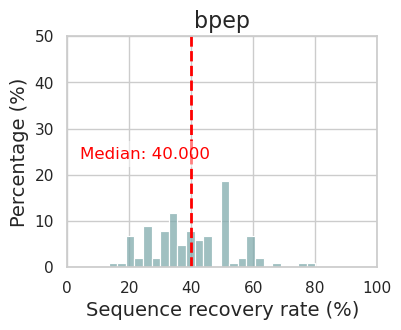

In [66]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='bpep'].copy(), db_name='bpep', output_path='./metric_stat/pepdesign_seq_recovery_rate_bpep.png')

In [67]:
# plot_seq_recovery_hist(df_gen_merge, db_name='cpep', output_path='./metric_stat/pepdesign_seq_recovery_rate_cpep.png')

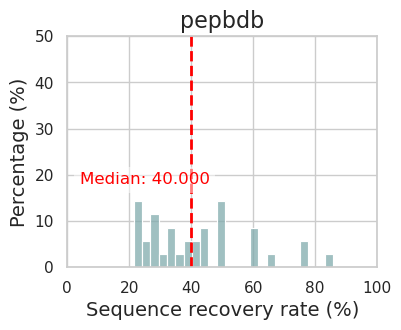

In [68]:
plot_seq_recovery_hist(df_gen_merge[df_gen_merge['db']=='pepbdb'].copy(), db_name='pepbdb', output_path='./metric_stat/pepdesign_seq_recovery_rate_pepbdb.png')

### Ramachandran

In [7]:
# best cfd_traj
target_cols = ['total_angle_numbers', 'total_accept', 'total_favoured']
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_merge_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + target_cols].reset_index(drop=True)

In [18]:
def cal_rama_stats(df_metric):
    df_rama_stats = df_metric.groupby('db')[['total_angle_numbers', 'total_accept', 'total_favoured']].sum().reset_index()
    df_rama_stats['favoured_ratio'] = (df_rama_stats['total_favoured'] / df_rama_stats['total_angle_numbers']) * 100
    df_rama_stats['accept_ratio'] = (df_rama_stats['total_accept'] / df_rama_stats['total_angle_numbers']) * 100
    return df_rama_stats

In [19]:
df_rama_stats_mean = cal_rama_stats(df_gen_merge)
df_rama_stats_best_cfd = cal_rama_stats(df_merge_best_cfd)

In [32]:
df_rama_combined = pd.merge(
    df_rama_stats_mean[['db', 'accept_ratio', 'favoured_ratio']], 
    df_rama_stats_best_cfd[['db', 'accept_ratio', 'favoured_ratio']], 
    on='db', 
    suffixes=('_mean', '_best_cfd')
)

ratio_cols = [col for col in df_rama_combined.columns if col != 'db']
for col in ratio_cols:
    df_rama_combined[col] = df_rama_combined[col].apply(lambda x: f"{x:.2f}%")

In [33]:
df_rama_combined

,db,accept_ratio_mean,favoured_ratio_mean,accept_ratio_best_cfd,favoured_ratio_best_cfd
0,bpep,72.44%,53.08%,81.74%,62.96%
1,pepbdb,72.59%,53.69%,77.08%,61.26%


In [34]:
df_rama_combined.to_csv('./metric_stat/pepdesign_rama_stats.csv', index=False)

### Secondary structure

In [7]:
def get_ss_distribution(df, col_name):
    results = []
    for db_name, group in df.groupby('db'):
        # 将该组所有序列连成一个长字符串，并转为 List（每个字符是一个元素）
        all_chars = list("".join(group[col_name].astype(str)))
        
        counts = pd.Series(all_chars).value_counts()
        
        counts['db'] = db_name
        results.append(counts)

    return pd.DataFrame(results).set_index('db').fillna(0).astype(int)


def map_ss_to_categories(df_counts):
    
    dssp_mapping = {
        'Helix (H, G, I)': ['H', 'G', 'I'],
        'Turn (T)': ['T'],
        'Bend (S)': ['S'],
        'Coil (-)': ['-'],
        'Others (E, B)': ['E', 'B']
    }
    
    df_mapped = pd.DataFrame(index=df_counts.index)
    
    for category, chars in dssp_mapping.items():
        existing_chars = [c for c in chars if c in df_counts.columns]
        if existing_chars:
            # 将这些列求和归并为一列
            df_mapped[category] = df_counts[existing_chars].sum(axis=1)
        else:
            # 如果该分类下的所有字符都不存在, 设为 0
            df_mapped[category] = 0
            
    return df_mapped

In [8]:
# ground truth - 保留所有数据, 不能被tag过滤
df_ss_gt_full = df_gen_merge_full[['data_id', 'db', 'ss_gt']].drop_duplicates()

In [9]:
# best cfd_traj
idx = df_gen_merge.groupby('data_id')['cfd_traj'].idxmax() # index with max cfd_traj
df_ss_best_cfd = df_gen_merge.loc[idx, ['data_id', 'db', 'cfd_traj'] + ['ss']].reset_index(drop=True)

In [10]:
# Stat: H/G/I/T/S/E/B/-
df_ss_stat_mean = get_ss_distribution(df_gen_merge, 'ss')
df_ss_stat_best_cfd = get_ss_distribution(df_ss_best_cfd, 'ss')
df_ss_gt_stat = get_ss_distribution(df_ss_gt_full, 'ss_gt')

In [11]:
# Stat: Helix, Turn, Bend, Coil, Others
df_ss_mapped_mean = map_ss_to_categories(df_ss_stat_mean)
df_ss_mapped_best_cfd = map_ss_to_categories(df_ss_stat_best_cfd)
df_ss_gt_mapped = map_ss_to_categories(df_ss_gt_stat)

In [12]:
# Percentage
df_ss_percent_mean = df_ss_mapped_mean.div(df_ss_mapped_mean.sum(axis=1), axis=0) * 100
df_ss_percent_best_cfd = df_ss_mapped_best_cfd.div(df_ss_mapped_best_cfd.sum(axis=1), axis=0) * 100
df_ss_gt_percent = df_ss_gt_mapped.div(df_ss_gt_mapped.sum(axis=1), axis=0) * 100

In [21]:
def prepare_plot_data(df_percent, label):
    df_long = df_percent.reset_index().melt(id_vars='db', var_name='SS_Type', value_name='Percentage')
    df_long['Source'] = label
    display_map = {
        'Coil (-)': 'Coil', 'Helix (H, G, I)': 'Helix', 'Bend (S)': 'Bend', 
        'Turn (T)': 'Turn', 'Others (E, B)': 'Others'
    }
    df_long['SS_Type'] = df_long['SS_Type'].map(display_map)
    return df_long

df_pred_mean = prepare_plot_data(df_ss_percent_mean, 'Mean')
df_pred_best_cfd = prepare_plot_data(df_ss_percent_best_cfd, 'Best cfd_traj')
df_gt = prepare_plot_data(df_ss_gt_percent, 'Ground Truth')

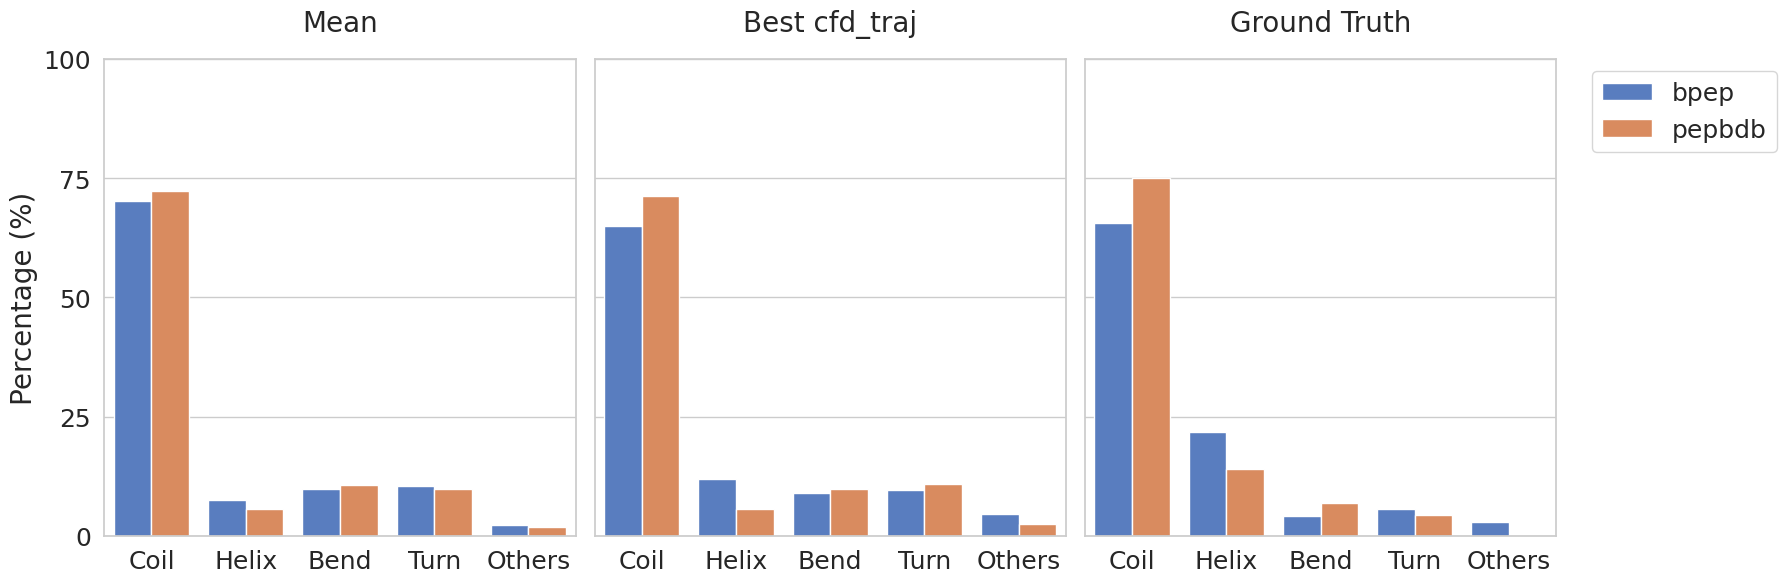

In [29]:
ss_order = ['Coil', 'Helix', 'Bend', 'Turn', 'Others']
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

plot_datasets = [
    ("Mean", df_pred_mean, axes[0]),
    ("Best cfd_traj", df_pred_best_cfd, axes[1]),
    ("Ground Truth", df_gt, axes[2])
]

for i, (title, data, ax) in enumerate(plot_datasets):
    # 绘图：x为结构类型，hue为db分组
    sns.barplot(
        data=data,
        x='SS_Type',
        y='Percentage',
        hue='db',
        order=ss_order,
        palette='muted',
        ax=ax
    )
        
    # 细节设置
    ax.set_title(title, fontsize=20, pad=20)
    ax.set_xlabel('', fontsize=16)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=18)
    
    # 只有左侧图保留 Y 轴标签
    if ax == axes[0]:
        ax.set_ylabel('Percentage (%)', fontsize=20)
    else:
        ax.set_ylabel('')

    if i < 2:
        # 前两个图去掉图例
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        # 最后一个图保留图例并放到右侧外
        ax.legend(title='', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=18)

plt.tight_layout()
plt.savefig('./metric_stat/pepdesign_ss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()